# Preprocessing and Pipelines

### Table of contents
0. [Introduction](#0.-Introduction)
1. [Setup](#1.-Setup)
2. [A quick look at the missing values](#2.-A-quick-look-at-the-missing-values)
3. [Missing Values](#3.-Missing-Values)
4. [Feature Scaling](#4.-Feature-Scaling)
5. [Engineering a categorical feature: coast_region](#5.-Engineering-a-categorical-feature:-coast_region)
6. [Categorical Encoding](#6.-Categorical-Encoding)
7. [Feature Engineering](#7.-Feature-Engineering)
8. [Doing it by hand](#8.-Doing-it-by-hand)
9. [Pipeline: one object instead of many steps](#9.-Pipeline:-one-object-instead-of-many-steps)
10. [ColumnTransformer: different columns, different treatment](#10.-ColumnTransformer:-different-columns,-different-treatment)
11. [Data leakage, one more time, at the Pipeline level](#11.-Data-leakage,-one-more-time,-at-the-Pipeline-level)
12. [Summary](#12.-Summary)

## 0. Introduction

Week 2 punched holes into `AveBedrms` and `AveRooms` and cleaned them by hand. This notebook does the same job with real `scikit-learn` objects, adds encoding and feature engineering, then wraps everything into one `Pipeline` and `ColumnTransformer`. One rule recurs throughout: fit only on training data.

## 1. Setup

Same dataset and synthetic damage as week 2, same seed.

In [1]:
import numpy as np
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing(as_frame=True)
housing = california.frame

rng = np.random.default_rng(42)
messy = housing.copy()

missing_idx = rng.choice(messy.index, size=200, replace=False)
messy.loc[missing_idx, "AveBedrms"] = np.nan

missing_idx_2 = rng.choice(messy.index, size=120, replace=False)
messy.loc[missing_idx_2, "AveRooms"] = np.nan

messy.isna().sum()

MedInc           0
HouseAge         0
AveRooms       120
AveBedrms      200
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseVal      0
dtype: int64

Split first, before touching missing values or scale.

In [2]:
from sklearn.model_selection import train_test_split

X = messy.drop(columns="MedHouseVal")
y = messy["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

## 2. A quick look at the missing values

In [3]:
missing_pct = X_train.isna().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0]

AveBedrms    0.999273
AveRooms     0.605620
dtype: float64

`AveRooms` also has real outliers, useful in section 3.2.

In [4]:
X_train["AveRooms"].sort_values(ascending=False).head()

1914     141.909091
12447     62.422222
1913      61.812500
11862     59.875000
1912      56.269231
Name: AveRooms, dtype: float64

## 3. Missing Values

### 3.1 Strategy 1: drop the rows

In [5]:
dropped = X_train.dropna(subset=["AveBedrms", "AveRooms"])
print("before:", X_train.shape, " after:", dropped.shape)

before: (16512, 8)  after: (16249, 8)


About 2.5% of rows gone, fine here, not a rule to apply by reflex.

### 3.2 Strategy 2: impute, mean vs median

In [6]:
mean_fill = X_train["AveRooms"].mean()
median_fill = X_train["AveRooms"].median()
print(f"mean:   {mean_fill:.2f}")
print(f"median: {median_fill:.2f}")

mean:   5.44
median: 5.24


The outliers pull the mean up; median is the safer default.

### 3.3 `SimpleImputer`: fit only on training data

In [7]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
imputer.fit(X_train[["AveBedrms", "AveRooms"]])

X_train_imputed = X_train.copy()
X_train_imputed[["AveBedrms", "AveRooms"]] = imputer.transform(X_train[["AveBedrms", "AveRooms"]])

X_test_imputed = X_test.copy()
X_test_imputed[["AveBedrms", "AveRooms"]] = imputer.transform(X_test[["AveBedrms", "AveRooms"]])

imputer.statistics_

array([1.04938272, 5.23581984])

Learned from `X_train` alone; `X_test` never contributed.

In [8]:
X_train_imputed.isna().sum().sum(), X_test_imputed.isna().sum().sum()

(np.int64(0), np.int64(0))

## 4. Feature Scaling

### 4.1 Why scale

In [9]:
X_train_imputed[["Population", "HouseAge"]].describe().loc[["min", "max"]]

,Population,HouseAge
min,3.0,1.0
max,35682.0,52.0


Wildly different ranges; distance- and coefficient-based models would let `Population` dominate.

### 4.2 `StandardScaler`

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_imputed)

X_train_scaled = scaler.transform(X_train_imputed)
X_train_scaled[:, :3].mean(axis=0).round(2), X_train_scaled[:, :3].std(axis=0).round(2)

(array([-0., -0., -0.]), array([1., 1., 1.]))

Mean 0, std 1, based on train statistics only.

### 4.3 Fit only on train, here too

In [11]:
import pandas as pd

combined_imputed = pd.concat([X_train_imputed, X_test_imputed])

scaler_leaky = StandardScaler().fit(combined_imputed)
scaler_correct = StandardScaler().fit(X_train_imputed)

pd.DataFrame({
    "fit on train + test (leaky)": scaler_leaky.mean_,
    "fit on train only (correct)": scaler_correct.mean_,
}, index=X_train_imputed.columns).round(3)

,fit on train + test (leaky),fit on train only (correct)
MedInc,3.871,3.881
HouseAge,28.639,28.608
AveRooms,5.428,5.434
AveBedrms,1.096,1.096
Population,1425.477,1426.453
AveOccup,3.071,3.097
Latitude,35.632,35.643
Longitude,-119.570,-119.582


Small gap here, but always an invisible, optimistic leak.

## 5. Engineering a categorical feature: `coast_region`

`fetch_california_housing` has no categorical column, so we build one from `Longitude`: California's coast runs north-south, so three bins give a real nominal category.

In [12]:
def add_coast_region(df):
    df = df.copy()
    df["coast_region"] = pd.cut(
        df["Longitude"],
        bins=[-125, -121.22, -118.20, -114],
        labels=["Coastal", "Central", "Inland"],
    )
    return df

X_train = add_coast_region(X_train)
X_test = add_coast_region(X_test)

X_train["coast_region"].value_counts()

coast_region
Inland     5567
Coastal    5503
Central    5442
Name: count, dtype: int64

## 6. Categorical Encoding

### 6.1 Ordinal Encoding: `income_cat`

`MedInc` has a real order, so binning it gives an ordinal category.

In [13]:
def add_income_cat(df):
    df = df.copy()
    df["income_cat"] = pd.cut(
        df["MedInc"],
        bins=[0, 2.5, 4.5, 7, np.inf],
        labels=["Low", "Medium", "High", "Very High"],
    )
    return df

X_train = add_income_cat(X_train)
X_test = add_income_cat(X_test)

from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(categories=[["Low", "Medium", "High", "Very High"]])
ordinal_encoder.fit(X_train[["income_cat"]])
ordinal_encoder.transform(X_train[["income_cat"]])[:5]

array([[1.],
       [1.],
       [1.],
       [0.],
       [1.]])

`categories=` pins the order; without it, `OrdinalEncoder` assigns alphabetically.

### 6.2 One-Hot Encoding: `coast_region`

No real order, so one-hot instead.

In [14]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(sparse_output=False)
onehot_encoder.fit(X_train[["coast_region"]])

encoded = onehot_encoder.transform(X_train[["coast_region"]])
pd.DataFrame(encoded, columns=onehot_encoder.get_feature_names_out(), index=X_train.index).head()

,coast_region_Central,coast_region_Coastal,coast_region_Inland
14196,0.0,0.0,1.0
8267,0.0,0.0,1.0
17445,1.0,0.0,0.0
14265,0.0,0.0,1.0
2271,1.0,0.0,0.0


### 6.3 A category the encoder has never seen

In [15]:
X_train_partial = X_train[X_train["coast_region"] != "Inland"]

strict_encoder = OneHotEncoder(sparse_output=False)
strict_encoder.fit(X_train_partial[["coast_region"]])

try:
    strict_encoder.transform(X_test[["coast_region"]])
except ValueError as e:
    print("ValueError:", e)

ValueError: Found unknown categories ['Inland'] in column 0 during transform


`handle_unknown="ignore"` swaps that crash for a row of zeros.

In [16]:
lenient_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
lenient_encoder.fit(X_train_partial[["coast_region"]])

lenient_encoder.transform(X_test[["coast_region"]])[:5]

array([[1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.]])

## 7. Feature Engineering

### 7.1 Why it matters

Garbage in, garbage out. Three parts: selection, extraction, gathering new data.

### 7.2 Feature Selection

`RandomForestRegressor.feature_importances_`, from week 5.

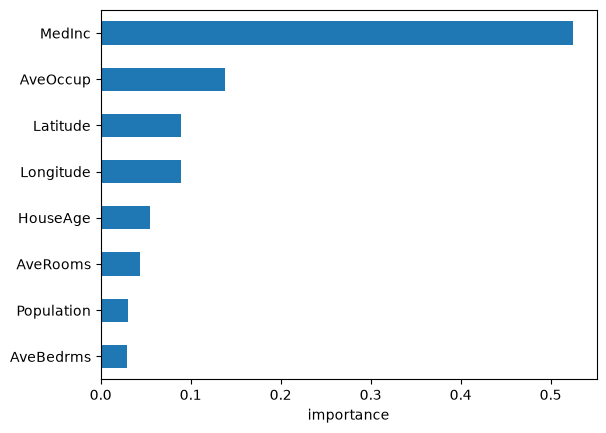

In [17]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

numeric_cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]
X_train_numeric = X_train[numeric_cols].fillna(X_train[numeric_cols].median())

forest = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
forest.fit(X_train_numeric, y_train)

pd.Series(forest.feature_importances_, index=numeric_cols).sort_values().plot(kind="barh")
plt.xlabel("importance")
plt.show()

`AveOccup` and `MedInc` matter most; `HouseAge` least.

### 7.3 Feature Extraction: ratio features

In [18]:
def add_ratio_features(df):
    df = df.copy()
    df["bedrooms_ratio"] = df["AveBedrms"] / df["AveRooms"]
    df["rooms_per_person"] = df["AveRooms"] / df["AveOccup"]
    return df

X_train = add_ratio_features(X_train)
X_test = add_ratio_features(X_test)

X_train[["AveRooms", "AveBedrms", "AveOccup", "bedrooms_ratio", "rooms_per_person"]].head()

,AveRooms,AveBedrms,AveOccup,bedrooms_ratio,rooms_per_person
14196,5.017657,1.006421,3.691814,0.200576,1.359130
8267,4.473545,1.041005,1.738095,0.232703,2.573820
17445,5.645833,0.985119,2.723214,0.174486,2.073224
14265,4.002817,1.033803,3.994366,0.258269,1.002116
2271,6.268421,1.134211,2.300000,0.180940,2.725400


More meaningful than either raw column alone.

### 7.4 Creating new features from new data

When neither selection nor extraction is enough, the fix is to go find more data, not reshuffle what's here.

## 8. Doing it by hand

`X_train` is still unimputed. Same steps as sections 3, 4, and 6, all by hand, in one place.

In [19]:
numeric_features = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]
categorical_features = ["coast_region"]

num_imputer = SimpleImputer(strategy="median")
num_imputer.fit(X_train[numeric_features])
X_train_num = num_imputer.transform(X_train[numeric_features])
X_test_num = num_imputer.transform(X_test[numeric_features])

num_scaler = StandardScaler()
num_scaler.fit(X_train_num)
X_train_num = num_scaler.transform(X_train_num)
X_test_num = num_scaler.transform(X_test_num)

cat_imputer = SimpleImputer(strategy="most_frequent")
cat_imputer.fit(X_train[categorical_features])
X_train_cat = cat_imputer.transform(X_train[categorical_features])
X_test_cat = cat_imputer.transform(X_test[categorical_features])

cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
cat_encoder.fit(X_train_cat)
X_train_cat = cat_encoder.transform(X_train_cat)
X_test_cat = cat_encoder.transform(X_test_cat)

X_train_num.shape, X_train_cat.shape

((16512, 8), (16512, 3))

Six `fit`/`transform` calls, two branches, easy to get wrong.

## 9. Pipeline: one object instead of many steps

Week 3 used `make_pipeline`; `Pipeline` does the same with named steps, needed once we nest it inside `ColumnTransformer`.

In [20]:
from sklearn.pipeline import Pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_pipeline.fit(X_train[numeric_features])
numeric_pipeline.transform(X_train[numeric_features])[:3]

array([[-0.326196  ,  0.34849025, -0.17463485, -0.20801018,  0.76827628,
         0.05137609, -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40277045, -0.12806358, -0.09890135,
        -0.11736222, -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08874772, -0.25725104, -0.44981806,
        -0.03227969, -0.46014647, -0.44760309]])

`named_steps` exposes each fitted piece.

In [21]:
numeric_pipeline.named_steps["imputer"].statistics_

array([ 3.54580000e+00,  2.90000000e+01,  5.23581984e+00,  1.04938272e+00,
        1.16700000e+03,  2.81723971e+00,  3.42600000e+01, -1.18510000e+02])

## 10. ColumnTransformer: different columns, different treatment

In [22]:
from sklearn.compose import ColumnTransformer

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

preprocessor.fit(X_train)
processed = preprocessor.transform(X_train)
processed.shape

(16512, 11)

`get_feature_names_out()` shows where each output column came from.

In [23]:
preprocessor.get_feature_names_out()

array(['numeric__MedInc', 'numeric__HouseAge', 'numeric__AveRooms',
       'numeric__AveBedrms', 'numeric__Population', 'numeric__AveOccup',
       'numeric__Latitude', 'numeric__Longitude',
       'categorical__coast_region_Central',
       'categorical__coast_region_Coastal',
       'categorical__coast_region_Inland'], dtype=object)

## 11. Data leakage, one more time, at the Pipeline level

In [24]:
full_data = pd.concat([X_train, X_test])

preprocessor_leaky = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])
preprocessor_leaky.fit(full_data)

leaky_medians = preprocessor_leaky.named_transformers_["numeric"].named_steps["imputer"].statistics_
correct_medians = preprocessor.named_transformers_["numeric"].named_steps["imputer"].statistics_

pd.DataFrame({
    "fit on train + test (leaky)": leaky_medians,
    "fit on train only (correct)": correct_medians,
}, index=numeric_features).round(3)

,fit on train + test (leaky),fit on train only (correct)
MedInc,3.535,3.546
HouseAge,29.000,29.000
AveRooms,5.229,5.236
AveBedrms,1.049,1.049
Population,1166.000,1167.000
AveOccup,2.818,2.817
Latitude,34.260,34.260
Longitude,-118.490,-118.510


Same invisible shift as section 4.3. `Pipeline`/`ColumnTransformer` don't prevent this by magic, they just make the correct pattern the natural one to write.

## 12. Summary

- `SimpleImputer(strategy="median")` beats mean whenever a column has outliers, like `AveRooms`.
- `StandardScaler` centers every feature to mean 0, std 1.
- `OrdinalEncoder` for ordered categories, `OneHotEncoder` for unordered; `handle_unknown="ignore"` for categories unseen at training time.
- Feature engineering: select, extract, or gather new data.
- The recurring rule: fit only on training data. `Pipeline` and `ColumnTransformer` make that the default shape of the code instead of something to remember.
- Next notebook: attaching a model and training the two together.